# Customer churn: prediction, retention decisions, and simulated impact
An end-to-end applied data science case study using your uploaded Telco customer file.

**Decision:** Which customers should receive a limited retention campaign, and under what assumptions could that campaign pay for itself?

**Google Colab instructions:** Upload this notebook to Colab, select a Python runtime, and choose **Runtime > Run all**. When section 2 displays the upload button, select your `WA_Fn-UseC_-Telco-Customer-Churn (1).csv` file. The remaining cells continue after upload. Upload the CSV again whenever you start a fresh runtime. No dataset is embedded in this notebook.

The notebook uses NumPy, pandas, SciPy, scikit-learn, Matplotlib, and seaborn. Package versions are printed below. The original analysis was validated on Python 3.12; this Colab upload adaptation has been checked locally with a simulated upload, but has not been executed on Colab.

The workflow has exactly ten stages. Tables, figures, interpretations, and the final resume statement are generated from your uploaded data. Monetary outputs use **currency units (CU)** because the file does not establish currency.

## 1) Business framing

**Client scenario.** A telecom retention team can contact up to 10% of a customer cohort. It needs a ranked list and an explanation of the trade-off between churn risk, customer value, and campaign cost.

**Unit and target.** One row represents a customer; `Churn = Yes` is the positive class. The supplied CSV has no observation dates, intervention outcomes, or independently verifiable prediction window. We therefore model the recorded churn label as a retrospective classification exercise. A future production model would require features frozen before a defined future churn window; this random split cannot establish prospective performance.

**Success criteria.** Average precision (AP) is the primary model-selection metric because positive-class retrieval matters. Report ROC-AUC, log loss, Brier score, precision, recall, F1, confusion counts, and top-10% lift/capture. Accuracy is secondary. A decision threshold and the contact budget solve different problems: the campaign uses a capacity-constrained ranking, regardless of the classification threshold.

**Evaluation contract.** Reserve 20% test data before exploration. Use 60% for EDA, hypothesis testing, preprocessing fits and three-fold model comparison. Use 20% validation for threshold selection, explanations and policy development. Select the model using training CV AP, calibrate with training-only CV, then evaluate the frozen model on the test cohort. Test outputs are descriptive evidence, not a basis for further tuning.

**Decision limits.** Churn risk is not treatment responsiveness. Associations cannot establish causes, and the simulation cannot demonstrate realized savings. Demographic variables are excluded from model inputs; their exclusion alone does not guarantee fairness. Consent, offer eligibility, and pre-outcome feature availability need operational confirmation.

In [1]:
from pathlib import Path
import io, gzip, base64, hashlib, platform, importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
    log_loss, precision_score, recall_score, f1_score, accuracy_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
    precision_recall_curve, silhouette_score)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans

SEED = 42
CONTACT_FRACTION = 0.10
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='colorblind', context='notebook')
plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 115,
                     'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.max_columns', 14)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
packages = ['numpy', 'pandas', 'scipy', 'scikit-learn', 'matplotlib', 'seaborn']
versions = {p: importlib.metadata.version(p) for p in packages}
print('Python:', platform.python_version())
display(pd.Series(versions, name='Version').to_frame())

Python: 3.13.15


,Version
numpy,2.1.3
pandas,2.2.3
scipy,1.16.3
scikit-learn,1.6.1
matplotlib,3.10.0
seaborn,0.13.2


## 2) Data cleaning

Source: the Telco customer CSV you upload in the next cell. The expected file is `WA_Fn-UseC_-Telco-Customer-Churn (1).csv`. The SHA-256 fingerprint below identifies your uploaded source bytes. No external data or inferred dates are added.

We strip whitespace, validate the schema and labels, remove only exact duplicate rows, and reject conflicting customer IDs. Blank `TotalCharges` values become missing numeric values; they are **not** silently set to zero. Negative financial values or invalid tenure trigger a visible failure. Imputation is deferred to training pipelines, so validation and test information cannot influence fitted preprocessing. Service states such as “No internet service” remain distinct categories.

In [2]:
from google.colab import files

print('Upload your Telco Customer Churn CSV file below.')
uploaded = files.upload()
if len(uploaded) != 1:
    raise ValueError('Please upload exactly one CSV file, then rerun this cell.')
filename, source_bytes = next(iter(uploaded.items()))
if not filename.lower().endswith('.csv'):
    raise ValueError('Please upload a .csv file.')
print('Uploaded:', filename)
print('Source SHA-256:', hashlib.sha256(source_bytes).hexdigest())
raw_df = pd.read_csv(io.BytesIO(source_bytes))
print('Raw shape:', raw_df.shape)
display(raw_df.head())

/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv


Saving WA_Fn-UseC_-Telco-Customer-Churn (1).csv to WA_Fn-UseC_-Telco-Customer-Churn (1) (1).csv
Uploaded: WA_Fn-UseC_-Telco-Customer-Churn (1) (1).csv
Source SHA-256: 88be4b93fbe0cc83421af1c503794c97c342eca914c1576db7c276e61d61358a
Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,...,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,...,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,...,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,...,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,...,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


In [3]:
expected = ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
assert set(raw_df.columns) == set(expected), 'Unexpected schema: review before proceeding'
df = raw_df.copy()
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].str.strip().replace('', np.nan)
exact_duplicates = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
assert df.customerID.notna().all() and df.customerID.is_unique, 'Missing/conflicting customer IDs'
assert set(df.Churn.dropna()) == {'Yes', 'No'} and df.Churn.notna().all()
conversion_audit = []
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    converted = pd.to_numeric(df[col], errors='coerce')
    unexpected = df[col].notna() & converted.isna()
    assert not unexpected.any(), f'Unexpected nonnumeric values in {col}'
    df[col] = converted
    conversion_audit.append({'field': col, 'missing': int(converted.isna().sum()),
                             'minimum': converted.min(), 'maximum': converted.max()})
assert df.tenure.notna().all() and df.MonthlyCharges.notna().all()
assert (df[['tenure', 'MonthlyCharges', 'TotalCharges']].dropna() >= 0).all().all()
assert (df.tenure % 1 == 0).all()
df['target'] = df.Churn.map({'No': 0, 'Yes': 1}).astype(int)
display(pd.DataFrame(conversion_audit))
print('Exact duplicate rows removed:', exact_duplicates)
display(df.loc[df.TotalCharges.isna(), ['tenure', 'MonthlyCharges', 'TotalCharges']].head(15))

trainval_idx, test_idx = train_test_split(df.index, test_size=0.20,
    stratify=df.target, random_state=SEED)
train_idx, val_idx = train_test_split(trainval_idx, test_size=0.25,
    stratify=df.loc[trainval_idx, 'target'], random_state=SEED)
assert not (set(train_idx) & set(val_idx) or set(train_idx) & set(test_idx) or set(val_idx) & set(test_idx))
assert len(train_idx) + len(val_idx) + len(test_idx) == len(df)
train = df.loc[train_idx].copy()
print(f'Train: {len(train_idx):,}; validation: {len(val_idx):,}; test: {len(test_idx):,}')
display(Markdown(f'**Data finding:** {len(df):,} unique customers remain. '
    f'{df.TotalCharges.isna().sum()} total-charge values are missing; '
    'training-fold medians will fill these values. The test cohort is now reserved.'))

,field,missing,minimum,maximum
0,tenure,0,0.0000,72.0000
1,MonthlyCharges,0,18.2500,118.7500
2,TotalCharges,11,18.8000,"8,684.8000"


Exact duplicate rows removed: 0


,tenure,MonthlyCharges,TotalCharges
488,0,52.5500,NaN
753,0,20.2500,NaN
936,0,80.8500,NaN
1082,0,25.7500,NaN
1340,0,56.0500,NaN
3331,0,19.8500,NaN
3826,0,25.3500,NaN
4380,0,20.0000,NaN
5218,0,19.7000,NaN
6670,0,73.3500,NaN


Train: 4,225; validation: 1,409; test: 1,409


**Data finding:** 7,043 unique customers remain. 11 total-charge values are missing; training-fold medians will fill these values. The test cohort is now reserved.

## 3) EDA

All exploratory findings below use the training cohort only. Compare group sizes alongside churn rates: small groups can produce unstable percentages. Monthly charges and tenure are measured in CU/month and months, respectively. Total charges are cumulative, which creates dependence on tenure; this motivates regularized models and caution with feature importance.

,count,mean,std,min,25%,50%,75%,max
tenure,"4,225.0000",32.2944,24.6679,0.0000,9.0000,29.0000,56.0000,72.0000
MonthlyCharges,"4,225.0000",64.7765,29.9892,18.4000,35.7500,70.4000,89.7500,118.7500
TotalCharges,"4,218.0000","2,287.8353","2,280.3244",18.8500,386.0500,"1,385.3000","3,832.9000","8,684.8000"


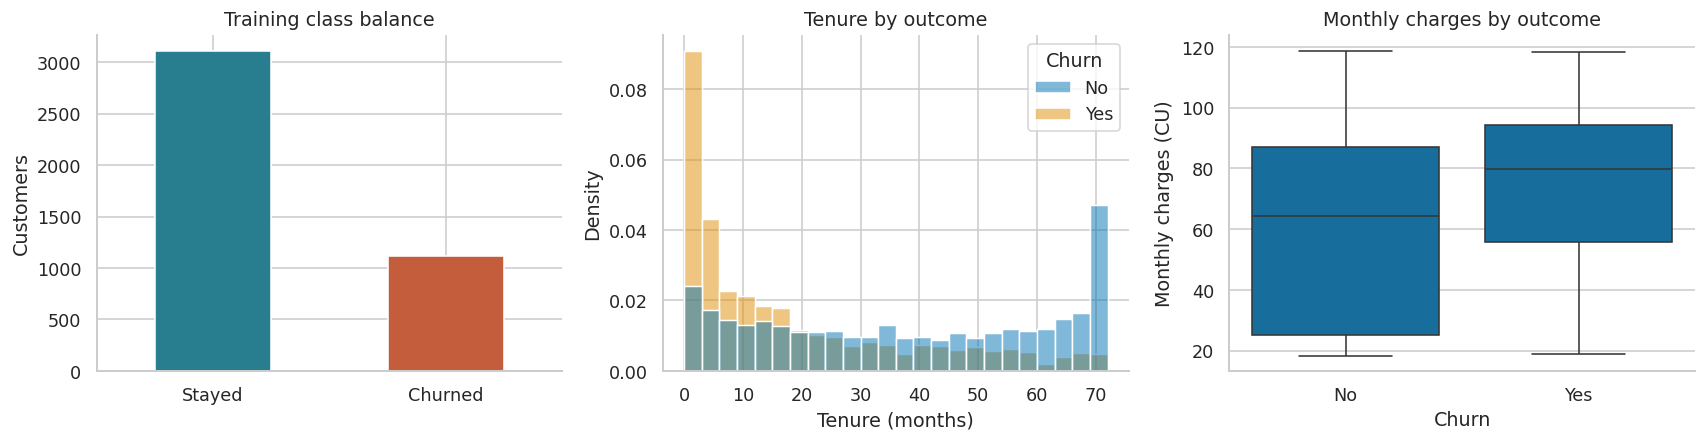

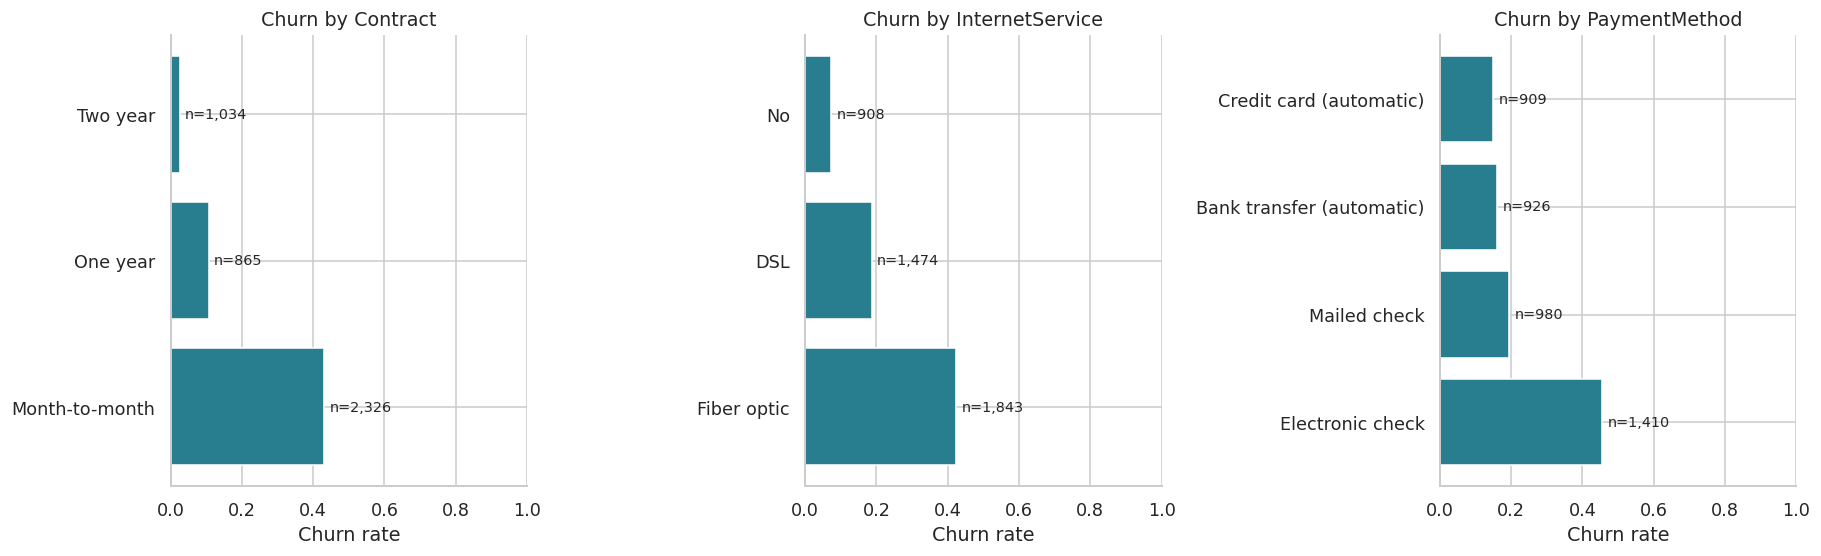

,customers,churners,churn_rate
Contract,,,
Month-to-month,2326,1002,0.4308
One year,865,93,0.1075
Two year,1034,26,0.0251


**Observed pattern:** Training churn prevalence is 26.5%. The highest contract-group churn rate is Month-to-month (43.1%). This is an association; customer selection and tenure can confound contract comparisons.

In [4]:
display(train[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().T)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
train.target.value_counts().sort_index().plot.bar(ax=axes[0], color=['#287D8E', '#C35D3C'])
axes[0].set(xticklabels=['Stayed', 'Churned'], title='Training class balance', ylabel='Customers', xlabel='')
axes[0].tick_params(axis='x', rotation=0)
sns.histplot(data=train, x='tenure', hue='Churn', bins=24, stat='density', common_norm=False, ax=axes[1])
axes[1].set(title='Tenure by outcome', xlabel='Tenure (months)')
sns.boxplot(data=train, x='Churn', y='MonthlyCharges', ax=axes[2])
axes[2].set(title='Monthly charges by outcome', ylabel='Monthly charges (CU)')
plt.tight_layout(); plt.show()

def rate_table(data, field):
    return data.groupby(field, observed=True).target.agg(customers='size', churners='sum', churn_rate='mean').sort_values('churn_rate', ascending=False)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Contract', 'InternetService', 'PaymentMethod']):
    tab = rate_table(train, col)
    ax.barh(tab.index, tab.churn_rate, color='#287D8E')
    ax.set(title=f'Churn by {col}', xlabel='Churn rate', xlim=(0, 1))
    for i, row in enumerate(tab.itertuples()):
        ax.text(row.churn_rate + .015, i, f'n={row.customers:,}', va='center', fontsize=9)
plt.tight_layout(); plt.show()
display(rate_table(train, 'Contract'))
rates = rate_table(train, 'Contract')
display(Markdown(f'**Observed pattern:** Training churn prevalence is {train.target.mean():.1%}. '
    f'The highest contract-group churn rate is {rates.index[0]} ({rates.iloc[0].churn_rate:.1%}). '
    'This is an association; customer selection and tenure can confound contract comparisons.'))

## 4) Hypothesis testing

Three exploratory questions are tested on training data: (a) is contract associated with churn, (b) is churn associated with the recorded technical-support state, and (c) do mean monthly charges differ between churners and non-churners? Chi-square tests use the full category tables, including “No internet service”; the latter is a different exposure state, so the support result is not the causal effect of providing support. Welch’s test allows unequal variances. Independent customer rows are assumed.

We report Cramér’s V for categorical association, the monthly-charge mean difference with a Welch 95% confidence interval, and Holm-adjusted p-values across the three tests. This correction does not remove selection bias from prior EDA; treat the tests as exploratory. Statistical significance does not establish intervention value.

In [5]:
tests = []
for field in ['Contract', 'TechSupport']:
    table = pd.crosstab(train[field], train.target)
    chi2, p, dof, expected_counts = stats.chi2_contingency(table, correction=False)
    assert expected_counts.min() >= 5, 'Sparse contingency table; use a suitable alternative'
    v = np.sqrt(chi2 / (table.to_numpy().sum() * min(table.shape[0]-1, table.shape[1]-1)))
    tests.append({'question': field + ' vs churn', 'test': 'Chi-square', 'p_raw': p,
                  'effect': v, 'effect_definition': "Cramer's V", 'minimum_expected_count': expected_counts.min()})
a = train.loc[train.target.eq(1), 'MonthlyCharges'].to_numpy()
b = train.loc[train.target.eq(0), 'MonthlyCharges'].to_numpy()
t, p = stats.ttest_ind(a, b, equal_var=False)
va, vb = a.var(ddof=1)/len(a), b.var(ddof=1)/len(b)
se = np.sqrt(va + vb)
dof = (va+vb)**2 / (va**2/(len(a)-1) + vb**2/(len(b)-1))
diff = a.mean() - b.mean()
ci = diff + np.array([-1, 1]) * stats.t.ppf(.975, dof) * se
tests.append({'question': 'Monthly charges vs churn', 'test': 'Welch t', 'p_raw': p,
              'effect': diff, 'effect_definition': 'Mean difference (CU/month)', 'minimum_expected_count': np.nan})
tests = pd.DataFrame(tests)
order = np.argsort(tests.p_raw.to_numpy())
adjusted = np.minimum(1, np.maximum.accumulate(tests.p_raw.to_numpy()[order] * np.arange(len(tests), 0, -1)))
tests['p_holm'] = np.nan
tests.loc[order, 'p_holm'] = adjusted
tests['reject_at_5pct'] = tests.p_holm < .05
test_display = tests.copy()
for col in ['p_raw', 'p_holm']:
    test_display[col] = test_display[col].map(lambda value: f'{value:.3e}')
display(test_display)
display(Markdown(f'Churners’ mean monthly charge minus non-churners’ is **{diff:.2f} CU/month**, '
    f'with a Welch 95% interval of **[{ci[0]:.2f}, {ci[1]:.2f}]**. '
    'Price reductions should be tested experimentally; this difference does not predict their effect.'))

,question,test,p_raw,effect,effect_definition,minimum_expected_count,p_holm,reject_at_5pct
0,Contract vs churn,Chi-square,4.170e-162,0.4194,Cramer's V,229.5065,1.251e-161,True
1,TechSupport vs churn,Chi-square,1.359e-110,0.3461,Cramer's V,240.9155,2.718e-110,True
2,Monthly charges vs churn,Welch t,2.556e-45,13.2917,Mean difference (CU/month),NaN,2.556e-45,True


Churners’ mean monthly charge minus non-churners’ is **13.29 CU/month**, with a Welch 95% interval of **[11.48, 15.10]**. Price reductions should be tested experimentally; this difference does not predict their effect.

## 5) Feature engineering

`customerID` is retained only for joins. The target and its text label are never predictors. Gender, senior-citizen status, partner, and dependents are excluded as a deliberate first-pass design choice. Remaining predictors must be audited for availability before churn in a real deployment.

Deterministic additions: first-year tenure, count of subscribed internet add-ons, count of streaming services, and cumulative charges divided by tenure (missing at zero tenure). The latter is a rough historical billing average, not a lifetime-value estimate. It can be redundant with existing charge fields. No target encoding or outcome-derived features are used.

The full feature transformer, numeric median imputation with missing indicators, standardization, categorical imputation and one-hot encoding live inside each model pipeline. Every CV fold fits its own preprocessing. Unknown categories are ignored safely at scoring time. Dense encoding is reasonable for this small table.

In [6]:
EXCLUDED = ['customerID', 'Churn', 'target', 'gender', 'SeniorCitizen', 'Partner', 'Dependents']
features = [c for c in df.columns if c not in EXCLUDED]
X_train, y_train = train[features], train.target
X_val, y_val = df.loc[val_idx, features], df.loc[val_idx, 'target']
X_test, y_test = df.loc[test_idx, features], df.loc[test_idx, 'target']

class TelcoFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        out = X.copy()
        addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
        out['AddOnCount'] = out[addons].eq('Yes').sum(axis=1)
        out['StreamingCount'] = out[['StreamingTV', 'StreamingMovies']].eq('Yes').sum(axis=1)
        out['FirstYear'] = out.tenure.le(12).astype(int)
        out['HistoricalMonthlyAverage'] = out.TotalCharges / out.tenure.replace(0, np.nan)
        return out

numeric = Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)),
                    ('scale', StandardScaler())])
categorical = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))])
preprocessor = ColumnTransformer([
    ('numeric', numeric, make_column_selector(dtype_include=np.number)),
    ('category', categorical, make_column_selector(dtype_exclude=np.number))])
def make_pipeline(model):
    return Pipeline([('features', TelcoFeatures()), ('prepare', clone(preprocessor)), ('model', model)])

display(TelcoFeatures().transform(X_train).head())
assert not set(EXCLUDED) & set(X_train.columns)

,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaymentMethod,MonthlyCharges,TotalCharges,AddOnCount,StreamingCount,FirstYear,HistoricalMonthlyAverage
2312,18,Yes,No,No,No internet service,No internet service,No internet service,...,Mailed check,20.1000,401.8500,0,0,0,22.3250
5227,7,Yes,Yes,Fiber optic,No,No,No,...,Electronic check,96.2000,639.7000,0,2,1,91.3857
6404,52,Yes,Yes,Fiber optic,Yes,No,Yes,...,Electronic check,109.3000,"5,731.4000",3,2,0,110.2192
88,46,Yes,No,No,No internet service,No internet service,No internet service,...,Mailed check,19.9500,927.1000,0,0,0,20.1543
6496,40,Yes,Yes,Fiber optic,Yes,No,No,...,Electronic check,101.8500,"4,086.3000",1,2,0,102.1575


## 6) Model comparison

Compare a prevalence baseline, regularized logistic regression, random forest, and histogram gradient boosting. Hyperparameters below are a small fixed candidate set, not an exhaustive search. No oversampling or class weights are used, which avoids deliberately shifting class priors for probability estimation. Three-fold stratified CV on training data selects the highest mean AP. Fold standard deviations describe variability, not confidence intervals.

The winning architecture receives sigmoid calibration using training-only three-fold CV (each calibration fold is held out from its base model). Validation chooses the threshold maximizing F1. Test metrics are then computed once using that frozen model and threshold. Calibration is assessed with reliability, Brier score and log loss; it does not guarantee accurate individual probabilities.

,AP_mean,AP_sd,ROC_AUC_mean,Brier_mean
model,,,,
Random forest,0.6687,0.0067,0.8448,0.1348
Logistic regression,0.6655,0.0069,0.8476,0.1342
Histogram gradient boosting,0.6483,0.0119,0.8342,0.1403
Prevalence baseline,0.2653,0.0004,0.5000,0.1949


Selected using training CV: Random forest


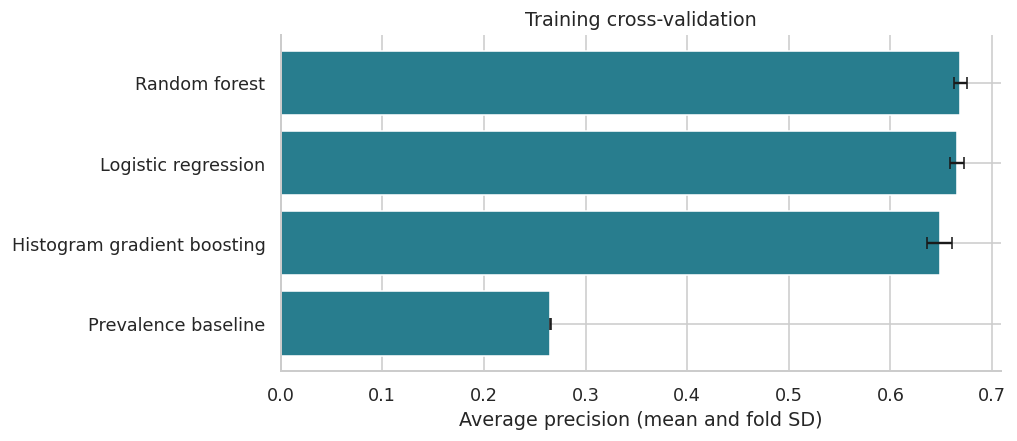

Validation-selected F1 threshold: 0.3132


,AP,ROC_AUC,Brier,Log_loss,Precision,Recall,F1,Accuracy,Top10_precision,Top10_capture,Top10_lift
Validation,0.6439,0.8387,0.1381,0.4295,0.6092,0.7086,0.6551,0.8020,0.7305,0.2754,2.7521
Test,0.6539,0.8421,0.1378,0.4262,0.5617,0.6818,0.6159,0.7743,0.7234,0.2727,2.7253


In [7]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
candidates = {
    'Prevalence baseline': DummyClassifier(strategy='prior'),
    'Logistic regression': LogisticRegression(C=1.0, max_iter=2000, random_state=SEED),
    'Random forest': RandomForestClassifier(n_estimators=200, min_samples_leaf=8,
                                            max_features='sqrt', random_state=SEED, n_jobs=1),
    'Histogram gradient boosting': HistGradientBoostingClassifier(max_iter=150,
                        max_leaf_nodes=15, l2_regularization=5, random_state=SEED)
}
cv_rows = []
for name, model in candidates.items():
    scores = cross_validate(make_pipeline(clone(model)), X_train, y_train, cv=cv, n_jobs=1,
        scoring={'AP': 'average_precision', 'ROC_AUC': 'roc_auc', 'Brier': 'neg_brier_score'})
    cv_rows.append({'model': name, 'AP_mean': scores['test_AP'].mean(),
        'AP_sd': scores['test_AP'].std(ddof=1), 'ROC_AUC_mean': scores['test_ROC_AUC'].mean(),
        'Brier_mean': -scores['test_Brier'].mean()})
comparison = pd.DataFrame(cv_rows).set_index('model').sort_values('AP_mean', ascending=False)
display(comparison)
winner = comparison.index[0]
print('Selected using training CV:', winner)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(comparison.index[::-1], comparison.AP_mean[::-1], xerr=comparison.AP_sd[::-1], color='#287D8E', capsize=4)
ax.set(xlabel='Average precision (mean and fold SD)', title='Training cross-validation')
plt.tight_layout(); plt.show()

final_model = CalibratedClassifierCV(make_pipeline(clone(candidates[winner])),
                                    method='sigmoid', cv=cv, n_jobs=1)
final_model.fit(X_train, y_train)
p_val = final_model.predict_proba(X_val)[:, 1]
pr, re, thresholds = precision_recall_curve(y_val, p_val)
f1s = 2 * pr[:-1] * re[:-1] / np.maximum(pr[:-1] + re[:-1], 1e-12)
threshold = float(thresholds[np.argmax(f1s)])
print(f'Validation-selected F1 threshold: {threshold:.4f}')

def top_indices(probability, fraction=CONTACT_FRACTION):
    k = max(1, int(np.ceil(len(probability) * fraction)))
    return np.argsort(-np.asarray(probability), kind='stable')[:k]
def metrics(y, p, threshold):
    y = np.asarray(y)
    pred = np.asarray(p) >= threshold
    top = top_indices(p)
    return {'AP': average_precision_score(y, p), 'ROC_AUC': roc_auc_score(y, p),
        'Brier': brier_score_loss(y, p), 'Log_loss': log_loss(y, p),
        'Precision': precision_score(y, pred, zero_division=0), 'Recall': recall_score(y, pred),
        'F1': f1_score(y, pred), 'Accuracy': accuracy_score(y, pred),
        'Top10_precision': y[top].mean(), 'Top10_capture': y[top].sum()/y.sum(),
        'Top10_lift': y[top].mean()/y.mean()}
p_test = final_model.predict_proba(X_test)[:, 1]
evaluation = pd.DataFrame({'Validation': metrics(y_val, p_val, threshold),
                           'Test': metrics(y_test, p_test, threshold)}).T
display(evaluation)
test_metrics = evaluation.loc['Test']

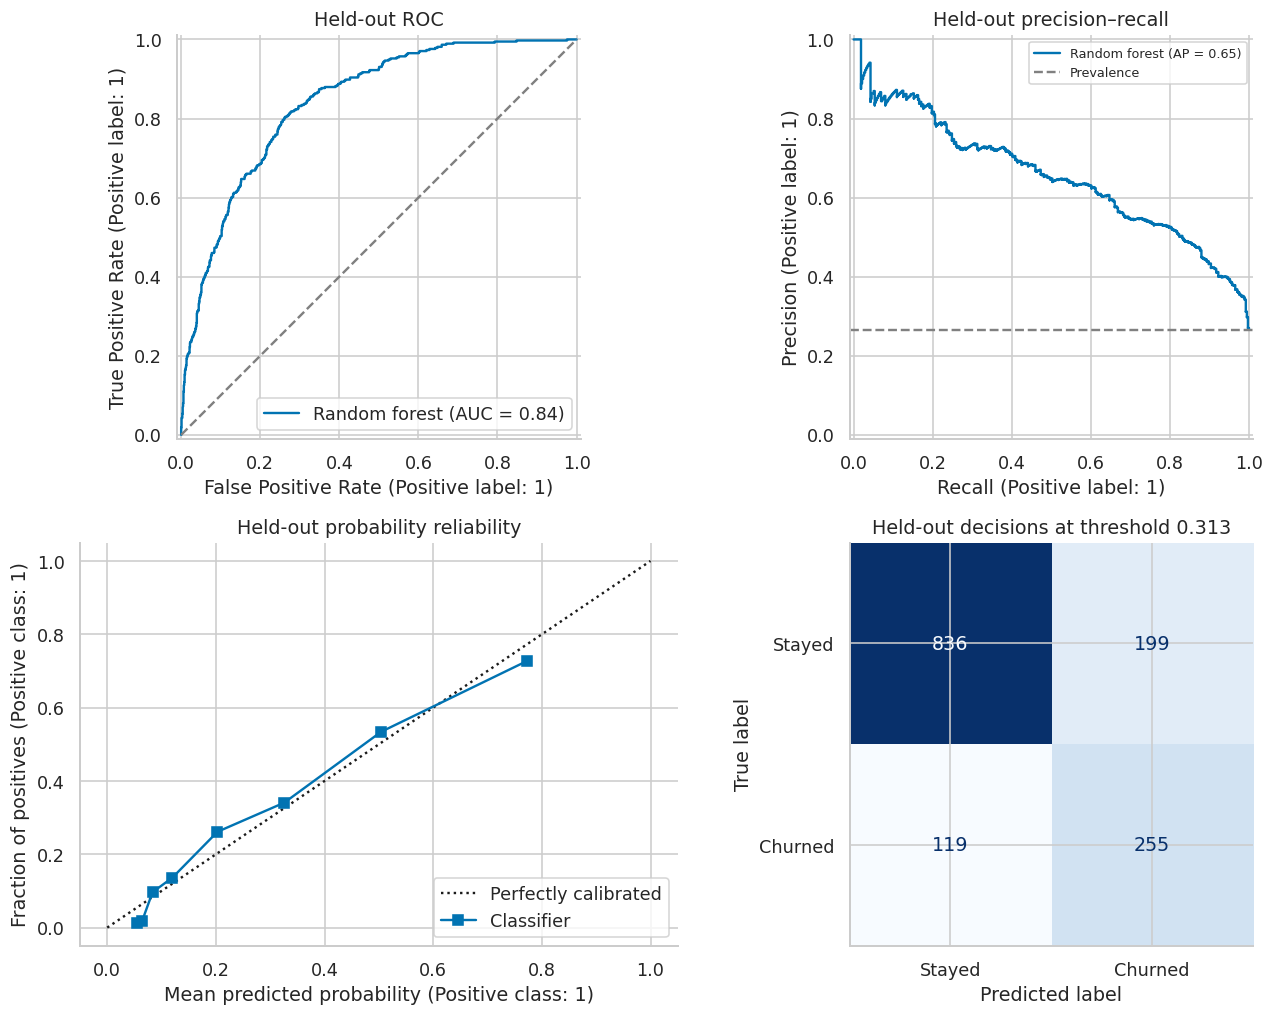

,2.5%,97.5%
AP,0.6048,0.7024
ROC_AUC,0.8180,0.8638


**Held-out finding:** Random forest achieves AP **0.654**, ROC-AUC **0.842**, and top-10% lift **2.73×**. The highest-risk 10% captures **27.3%** of observed test churners. Bootstrap intervals describe test-sample uncertainty conditional on this fitted model; they exclude retraining, model selection, and future population shifts.

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
RocCurveDisplay.from_predictions(y_test, p_test, ax=axes[0, 0], name=winner)
axes[0, 0].plot([0, 1], [0, 1], '--', color='gray'); axes[0, 0].set_title('Held-out ROC')
PrecisionRecallDisplay.from_predictions(y_test, p_test, ax=axes[0, 1], name=winner)
axes[0, 1].axhline(y_test.mean(), linestyle='--', color='gray', label='Prevalence')
axes[0, 1].legend(fontsize=8); axes[0, 1].set_title('Held-out precision–recall')
CalibrationDisplay.from_predictions(y_test, p_test, n_bins=8, strategy='quantile', ax=axes[1, 0])
axes[1, 0].set_title('Held-out probability reliability')
ConfusionMatrixDisplay.from_predictions(y_test, p_test >= threshold,
    display_labels=['Stayed', 'Churned'], ax=axes[1, 1], colorbar=False, cmap='Blues')
axes[1, 1].set_title(f'Held-out decisions at threshold {threshold:.3f}')
plt.tight_layout(); plt.show()

# Conditional bootstrap uncertainty for the fixed model; no refitting or selection.
rng = np.random.default_rng(SEED)
boot = []
yt = y_test.to_numpy()
for _ in range(500):
    sample = rng.integers(0, len(yt), len(yt))
    if np.unique(yt[sample]).size == 2:
        boot.append([average_precision_score(yt[sample], p_test[sample]),
                     roc_auc_score(yt[sample], p_test[sample])])
intervals = pd.DataFrame(np.quantile(boot, [.025, .975], axis=0).T,
                         index=['AP', 'ROC_AUC'], columns=['2.5%', '97.5%'])
display(intervals)
display(Markdown(f'**Held-out finding:** {winner} achieves AP **{test_metrics.AP:.3f}**, '
    f'ROC-AUC **{test_metrics.ROC_AUC:.3f}**, and top-10% lift **{test_metrics.Top10_lift:.2f}×**. '
    f'The highest-risk 10% captures **{test_metrics.Top10_capture:.1%}** of observed test churners. '
    'Bootstrap intervals describe test-sample uncertainty conditional on this fitted model; '
    'they exclude retraining, model selection, and future population shifts.'))

## 7) Model explainability

**Global explanation of the chosen model.** Permutation importance measures the validation AP decrease after shuffling an original input column; engineered descendants are recomputed by the pipeline. It therefore includes downstream effects of that input. Correlated predictors can substitute for one another, diluting individual importance. Negative values indicate no reliable benefit in this sample. Error bars are repeat standard deviations, not inferential intervals.

**Transparent reference model.** A logistic model fitted only on training data supplies coefficient directions and an exact additive log-odds explanation for one validation customer. It is a separate reference model, not an explanation of a different winning model or of the calibrated ensemble. Numeric coefficients are per standardized unit; categorical coefficients compare against the dropped reference level. Collinearity limits coefficient stability.

,feature,AP_decrease,repeat_SD
0,tenure,0.1462,0.0085
3,InternetService,0.0411,0.0105
10,Contract,0.0157,0.0060
14,TotalCharges,0.0143,0.0057
13,MonthlyCharges,0.0127,0.0063
4,OnlineSecurity,0.0105,0.0056
2,MultipleLines,0.0060,0.0015
7,TechSupport,0.0046,0.0047
5,OnlineBackup,0.0043,0.0035
11,PaperlessBilling,0.0031,0.0049


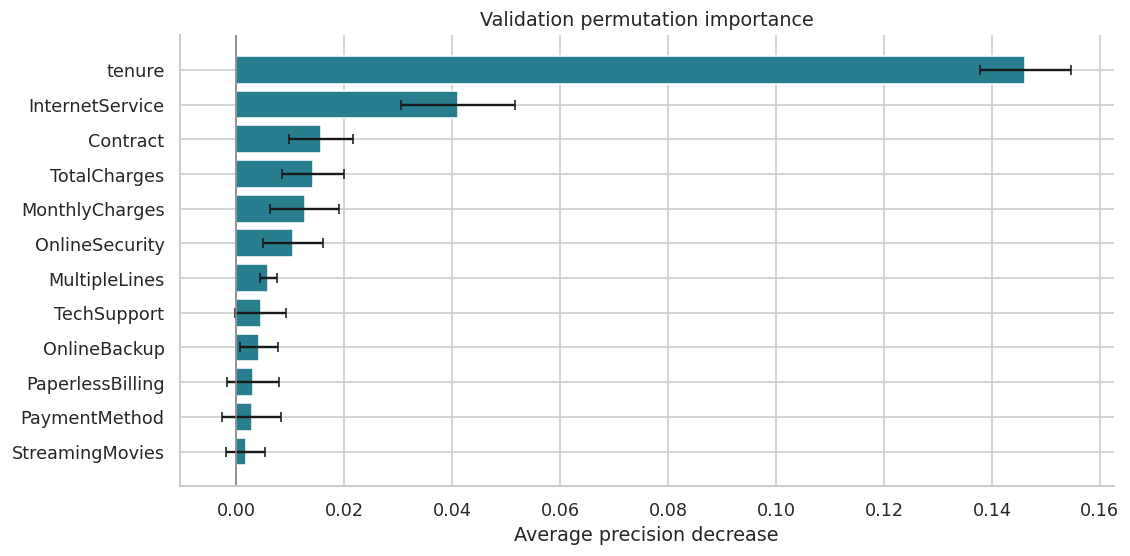

,feature,log_odds_coefficient
27,category__Contract_Two year,-1.6261
0,numeric__tenure,-0.9181
26,category__Contract_One year,-0.7694
9,category__PhoneService_Yes,-0.5236
15,category__OnlineSecurity_Yes,-0.3205
1,numeric__MonthlyCharges,-0.3119
4,numeric__StreamingCount,0.3005
28,category__PaperlessBilling_Yes,0.3334
30,category__PaymentMethod_Electronic check,0.3616
2,numeric__TotalCharges,0.3697


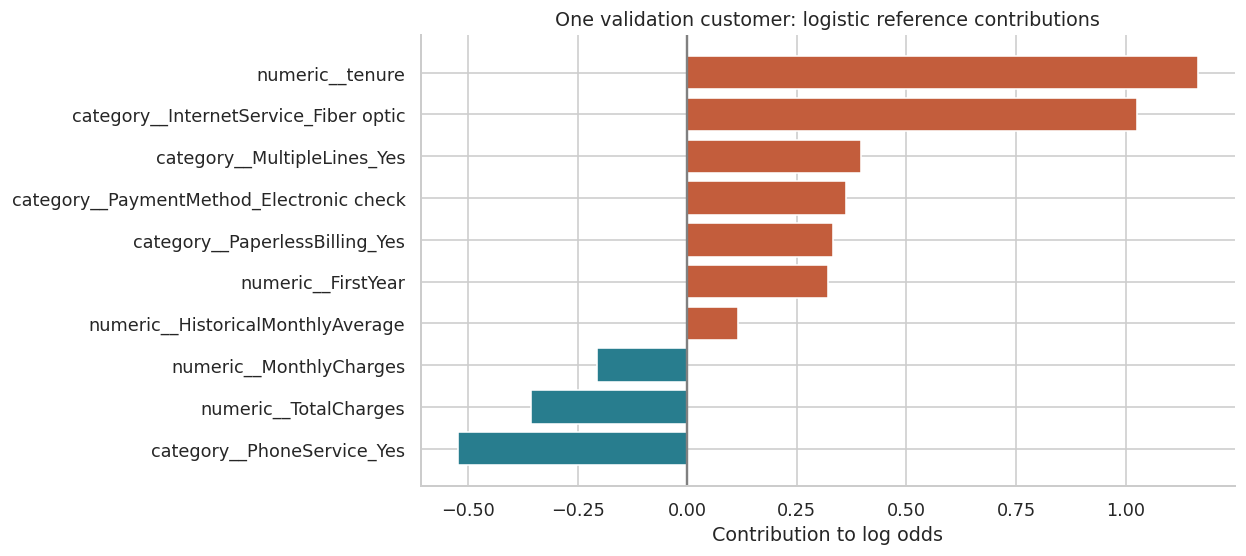

For this example, the reference-model probability is **82.7%** and the selected calibrated-model probability is **92.1%**. The plot shows the ten largest contributions; the reconstruction assertion uses every contribution plus the intercept. These explanations describe model behavior, not reasons an individual will leave.

In [9]:
perm = permutation_importance(final_model, X_val, y_val, scoring='average_precision',
                              n_repeats=6, random_state=SEED, n_jobs=1)
importance = pd.DataFrame({'feature': features, 'AP_decrease': perm.importances_mean,
                           'repeat_SD': perm.importances_std}).sort_values('AP_decrease', ascending=False)
display(importance)
shown = importance.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(shown.feature, shown.AP_decrease, xerr=shown.repeat_SD, color='#287D8E', capsize=3)
ax.axvline(0, color='gray', linewidth=1)
ax.set(title='Validation permutation importance', xlabel='Average precision decrease')
plt.tight_layout(); plt.show()

reference_model = make_pipeline(clone(candidates['Logistic regression'])).fit(X_train, y_train)
feature_names = reference_model.named_steps['prepare'].get_feature_names_out()
coeff = reference_model.named_steps['model'].coef_[0]
coef_table = pd.DataFrame({'feature': feature_names, 'log_odds_coefficient': coeff})
display(coef_table.loc[coef_table.log_odds_coefficient.abs().nlargest(12).index].sort_values('log_odds_coefficient'))
person_pos = int(np.argmax(p_val))
person = X_val.iloc[[person_pos]]
transformed = reference_model.named_steps['prepare'].transform(TelcoFeatures().transform(person))[0]
contributions = transformed * coeff
intercept = reference_model.named_steps['model'].intercept_[0]
local_probability = 1/(1 + np.exp(-(intercept + contributions.sum())))
assert np.isclose(local_probability, reference_model.predict_proba(person)[0, 1])
local = pd.Series(contributions, index=feature_names)
local = local.loc[local.abs().nlargest(10).index].sort_values()
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(local.index, local.values, color=np.where(local.values >= 0, '#C35D3C', '#287D8E'))
ax.axvline(0, color='gray'); ax.set(title='One validation customer: logistic reference contributions', xlabel='Contribution to log odds')
plt.tight_layout(); plt.show()
display(Markdown(f'For this example, the reference-model probability is **{local_probability:.1%}** '
    f'and the selected calibrated-model probability is **{p_val[person_pos]:.1%}**. '
    'The plot shows the ten largest contributions; the reconstruction assertion uses every contribution plus the intercept. '
    'These explanations describe model behavior, not reasons an individual will leave.'))

## 8) Customer segmentation

Create three behavioral segments from tenure, monthly charges, and subscribed-service counts. Three is fixed in advance to keep the outreach playbook manageable, not claimed as an optimal cluster count. K-means, imputation, and scaling fit on training data only. Churn labels and risk scores are excluded from clustering; validation labels are used only to describe the resulting segments. Cluster IDs are arbitrary. Silhouette is a diagnostic of separation, not evidence that the groups are natural or causal.

Training silhouette (sample up to 1,500): 0.344


,customers,tenure_months,monthly_CU,addons,streaming,mean_risk,observed_churn
segment,,,,,,,
0,331,19.5529,84.5056,1.0211,1.4169,0.4831,0.4834
1,643,23.4152,39.5393,0.4417,0.0233,0.2338,0.2442
2,435,57.5839,89.0569,2.7333,1.3977,0.1326,0.1310


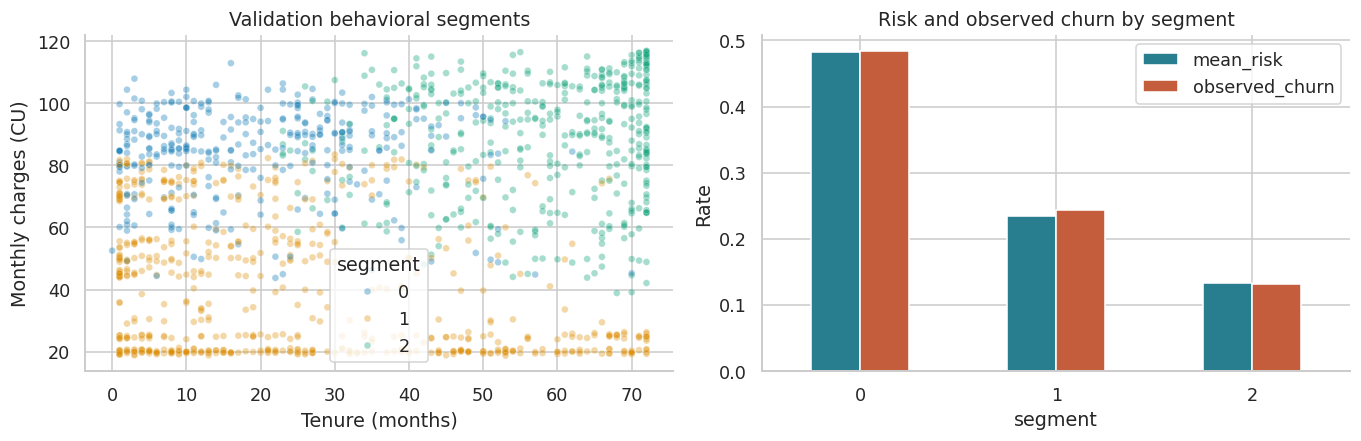

In [10]:
segment_features = ['tenure', 'MonthlyCharges', 'AddOnCount', 'StreamingCount']
seg_train = TelcoFeatures().transform(X_train)[segment_features]
seg_val = TelcoFeatures().transform(X_val)[segment_features]
seg_test = TelcoFeatures().transform(X_test)[segment_features]
segmenter = Pipeline([('impute', SimpleImputer(strategy='median')),
                     ('scale', StandardScaler()),
                     ('cluster', KMeans(n_clusters=3, n_init=20, random_state=SEED))])
segmenter.fit(seg_train)
train_clusters = segmenter.predict(seg_train)
z_train = segmenter[:-1].transform(seg_train)
print('Training silhouette (sample up to 1,500):', round(silhouette_score(
    z_train, train_clusters, sample_size=min(1500, len(z_train)), random_state=SEED), 3))
val_clusters = segmenter.predict(seg_val)
seg_profile = seg_val.assign(segment=val_clusters, observed_churn=y_val.to_numpy(), risk=p_val)
profile = seg_profile.groupby('segment').agg(customers=('risk', 'size'),
    tenure_months=('tenure', 'mean'), monthly_CU=('MonthlyCharges', 'mean'),
    addons=('AddOnCount', 'mean'), streaming=('StreamingCount', 'mean'),
    mean_risk=('risk', 'mean'), observed_churn=('observed_churn', 'mean'))
display(profile)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=seg_profile, x='tenure', y='MonthlyCharges', hue='segment', palette='colorblind', alpha=.35, s=18, ax=axes[0])
axes[0].set(title='Validation behavioral segments', xlabel='Tenure (months)', ylabel='Monthly charges (CU)')
profile[['mean_risk', 'observed_churn']].plot.bar(ax=axes[1], color=['#287D8E', '#C35D3C'])
axes[1].set(title='Risk and observed churn by segment', ylabel='Rate'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 9) Retention strategy

**Proposed pilot.** Use the frozen model to rank a prospectively eligible cohort. At most 10% can be contacted. Compare a reproducible random campaign, highest-risk ranking, and expected-net-value ranking. Expected value combines predicted risk with a fixed six-month contribution estimate, a hypothetical incremental save rate, and a cost charged to **every** contact. Only positive expected-value customers are selected by the value policy, so capacity need not be filled. Ties are resolved by stable input order.

Risk and value policies are specified below before inspecting their test outcomes. The value calculation assumes response is constant across customers; this cannot substitute for uplift modeling. No observed churn label enters either scoring or targeting. The test cohort is a historical illustration, not a list of current customers eligible for contact.

**Illustrative offer:** 5 CU contact cost plus 20 CU offer cost per contacted customer, including those who would stay anyway. Assume a 20% chance of incrementally preventing churn among customers who would otherwise churn, six additional retained months, and a 40% contribution margin. These are editable scenario inputs, not estimates from the CSV. No fixed campaign overhead, discounting, repeat churn, or spillover is included.

In [11]:
ASSUMPTIONS = {'contact_cost_CU': 5.0, 'offer_cost_CU': 20.0,
    'incremental_save_probability': .20, 'retained_months': 6.0,
    'contribution_margin': .40, 'contact_fraction': CONTACT_FRACTION}
display(pd.Series(ASSUMPTIONS, name='Scenario input').to_frame())
def policy_table(X, probability, clusters, assumptions=ASSUMPTIONS):
    result = pd.DataFrame({'risk': np.asarray(probability),
        'monthly_CU': X.MonthlyCharges.to_numpy(), 'segment': clusters}, index=X.index)
    result['retained_contribution_CU'] = result.monthly_CU * assumptions['retained_months'] * assumptions['contribution_margin']
    cost = assumptions['contact_cost_CU'] + assumptions['offer_cost_CU']
    result['expected_net_CU'] = result.risk * assumptions['incremental_save_probability'] * result.retained_contribution_CU - cost
    k = int(np.ceil(len(result) * assumptions['contact_fraction']))
    result['Random'] = False
    result.loc[np.random.default_rng(SEED).choice(result.index, size=k, replace=False), 'Random'] = True
    result['Risk'] = False
    result.loc[result.sort_values('risk', ascending=False, kind='stable').head(k).index, 'Risk'] = True
    result['Value'] = False
    eligible = result[result.expected_net_CU > 0].sort_values('expected_net_CU', ascending=False, kind='stable').head(k)
    result.loc[eligible.index, 'Value'] = True
    assert result[['Random', 'Risk', 'Value']].sum().le(k).all()
    return result
validation_policy = policy_table(X_val, p_val, val_clusters)
display(validation_policy.groupby('segment').agg(customers=('risk', 'size'),
    mean_risk=('risk', 'mean'), value_contacts=('Value', 'sum'), risk_contacts=('Risk', 'sum')))

playbook = profile[['tenure_months', 'monthly_CU', 'mean_risk']].copy()
playbook['pilot_action'] = [
    'Onboarding and service-resolution call' if row.tenure_months < 24 else
    'Plan-fit and billing review' if row.monthly_CU > X_train.MonthlyCharges.median() else
    'Low-cost service check-in'
    for row in playbook.itertuples()]
display(playbook)
display(Markdown('Segment actions are hypotheses derived from the profiles. Use segments to tailor the conversation; '
    'the individual expected-value rule controls the illustrative paid campaign. Confirm offer eligibility and consent before any live use.'))

,Scenario input
contact_cost_CU,5.0000
offer_cost_CU,20.0000
incremental_save_probability,0.2000
retained_months,6.0000
contribution_margin,0.4000
contact_fraction,0.1000


,customers,mean_risk,value_contacts,risk_contacts
segment,,,,
0,331,0.4831,115,99
1,643,0.2338,26,42
2,435,0.1326,0,0


,tenure_months,monthly_CU,mean_risk,pilot_action
segment,,,,
0,19.5529,84.5056,0.4831,Onboarding and service-resolution call
1,23.4152,39.5393,0.2338,Onboarding and service-resolution call
2,57.5839,89.0569,0.1326,Plan-fit and billing review


Segment actions are hypotheses derived from the profiles. Use segments to tailor the conversation; the individual expected-value rule controls the illustrative paid campaign. Confirm offer eligibility and consent before any live use.

## 10) Business-impact simulation

For contacted customer *i*, let `p_i` be calibrated churn risk, `s` the incremental probability of saving an otherwise-churning customer, `V_i = monthly charges × retained months × contribution margin`, and `C` the all-in per-contact cost.

**Expected incremental net contribution = Σ contacted (p_i × s × V_i − C).** No-contact incremental contribution is zero. This is contribution saved relative to doing nothing, not total company profit, total revenue, or causal ROI measured in an experiment.

First compare the three frozen policies on the test cohort. Observed churn capture is a ranking diagnostic, while predicted savings use model probabilities and scenario inputs. Next show the risk-policy targeting curve and a sensitivity grid for the fixed value-policy contact list. Keeping that list fixed isolates assumption risk rather than reoptimizing with hindsight.

Finally run 5,000 Monte Carlo scenarios: draw one shared campaign save probability from Beta(6,24) (mean 20%, assumed uncertainty); draw each contacted customer's counterfactual churn from Bernoulli(`p_i`); and draw a save conditional on churn from Bernoulli(`s`). Costs apply to every contact, saved contributions only to incrementally saved customers. The 5th–95th percentiles are **scenario ranges**, not confidence intervals or forecast guarantees. This omits model uncertainty, uncertainty in margin/horizon, and dependence across customers beyond the shared save probability.

,contacts,observed_churners_contacted,observed_capture,expected_incremental_saves,campaign_cost_CU,expected_saved_contribution_CU,expected_net_CU,expected_ROI
policy,,,,,,,,
Random,141,32,0.0856,7.4306,"3,525.0000","1,310.2752","-2,214.7248",-0.6283
Risk,141,102,0.2727,22.6278,"3,525.0000","4,496.9623",971.9623,0.2757
Value,141,102,0.2727,22.3046,"3,525.0000","4,622.1763","1,097.1763",0.3113


Fixed value-policy break-even save probability: 15.3%


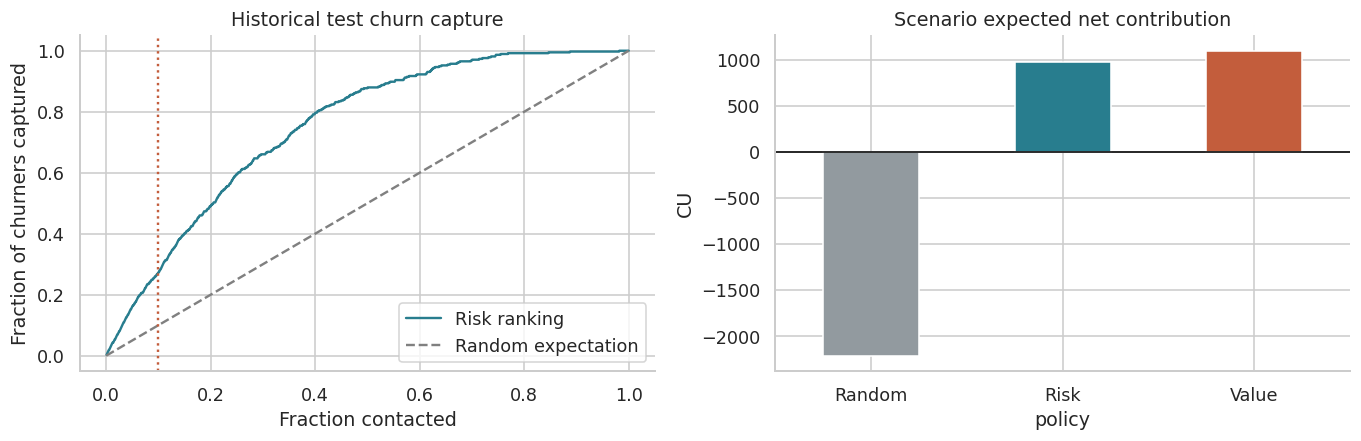

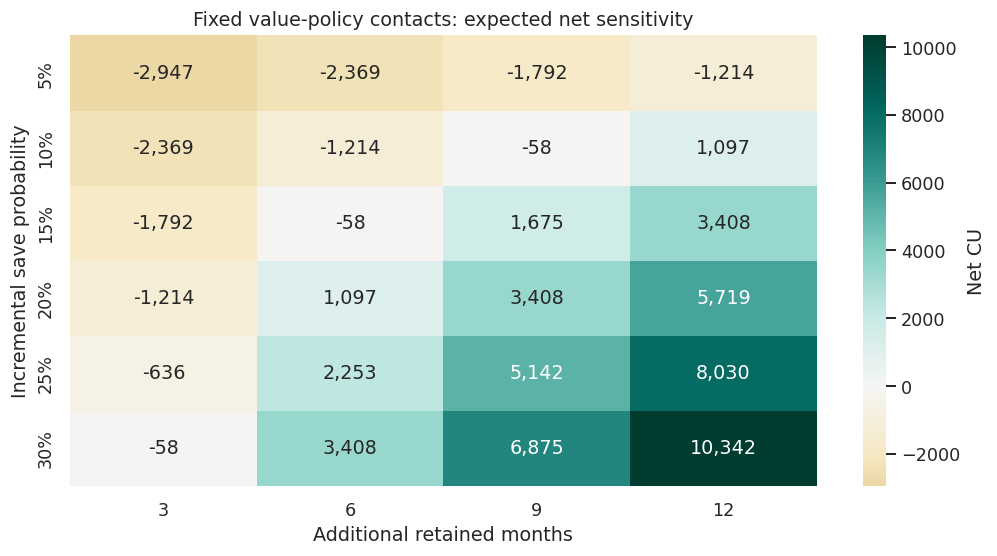

In [12]:
test_policy = policy_table(X_test, p_test, segmenter.predict(seg_test))
cost = ASSUMPTIONS['contact_cost_CU'] + ASSUMPTIONS['offer_cost_CU']
s = ASSUMPTIONS['incremental_save_probability']
impact_rows = []
for policy in ['Random', 'Risk', 'Value']:
    mask = test_policy[policy].to_numpy()
    selected = test_policy.loc[mask]
    spend = len(selected) * cost
    saved = (selected.risk * s).sum()
    benefit = (selected.risk * s * selected.retained_contribution_CU).sum()
    actual = y_test.to_numpy()[mask]
    impact_rows.append({'policy': policy, 'contacts': len(selected),
        'observed_churners_contacted': int(actual.sum()),
        'observed_capture': actual.sum()/y_test.sum(),
        'expected_incremental_saves': saved, 'campaign_cost_CU': spend,
        'expected_saved_contribution_CU': benefit, 'expected_net_CU': benefit-spend,
        'expected_ROI': (benefit-spend)/spend if spend else np.nan})
impact = pd.DataFrame(impact_rows).set_index('policy')
display(impact)
chosen = test_policy.loc[test_policy.Value]
weighted_value = (chosen.risk * chosen.retained_contribution_CU).sum()
break_even = len(chosen) * cost / weighted_value if weighted_value > 0 else np.nan
print(f'Fixed value-policy break-even save probability: {break_even:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = np.argsort(-p_test, kind='stable')
share = np.arange(1, len(y_test)+1)/len(y_test)
capture = np.cumsum(y_test.to_numpy()[order])/y_test.sum()
axes[0].plot(share, capture, color='#287D8E', label='Risk ranking')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Random expectation')
axes[0].axvline(CONTACT_FRACTION, linestyle=':', color='#C35D3C')
axes[0].set(title='Historical test churn capture', xlabel='Fraction contacted', ylabel='Fraction of churners captured')
axes[0].legend()
impact.expected_net_CU.plot.bar(ax=axes[1], color=['#929A9F', '#287D8E', '#C35D3C'])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set(title='Scenario expected net contribution', ylabel='CU'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

save_grid = np.array([.05, .10, .15, .20, .25, .30])
month_grid = np.array([3, 6, 9, 12])
sensitivity = pd.DataFrame(index=save_grid, columns=month_grid, dtype=float)
for save in save_grid:
    for months in month_grid:
        sensitivity.loc[save, months] = (chosen.risk * save * chosen.monthly_CU * months * ASSUMPTIONS['contribution_margin']).sum() - len(chosen)*cost
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(sensitivity, annot=True, fmt=',.0f', center=0, cmap='BrBG', ax=ax,
            yticklabels=[f'{v:.0%}' for v in save_grid], cbar_kws={'label': 'Net CU'})
ax.set(title='Fixed value-policy contacts: expected net sensitivity', xlabel='Additional retained months', ylabel='Incremental save probability')
plt.tight_layout(); plt.show()

,Monte Carlo result
contacts,141.0000
scenario_runs,"5,000.0000"
mean_net_CU,"1,091.7090"
median_net_CU,911.6400
5th_percentile_net_CU,"-1,660.9020"
95th_percentile_net_CU,"4,457.7960"
fraction_profitable,0.6950


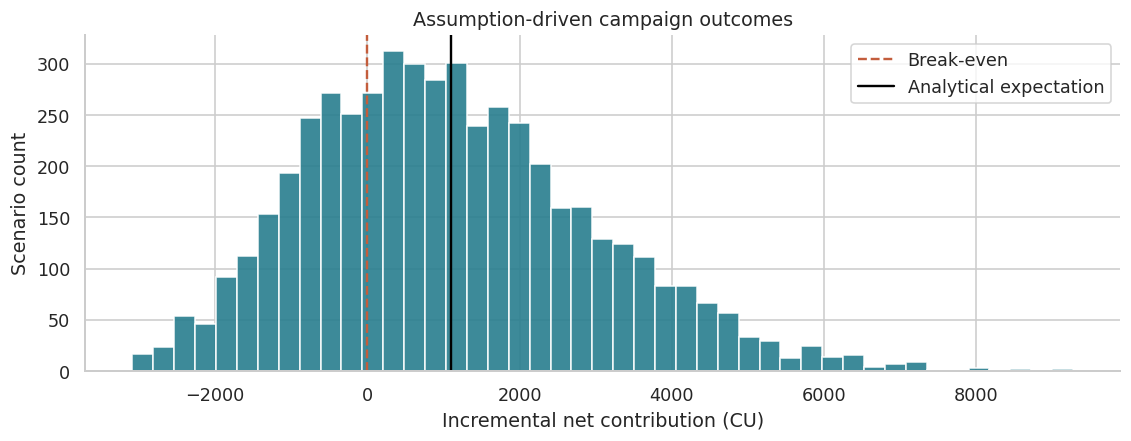

**Decision brief.** The model captures 27.3% of observed test churners in the highest-risk 10%, with 2.73× lift. Under the base assumptions, the value policy contacts 141 customers and has expected incremental net contribution of 1,097 CU. Its break-even incremental save probability is 15.3%; the scenario simulation produces positive net contribution in 69.5% of runs. These are hypothetical outcomes for this held-out cohort, not measured business savings.

In [13]:
rng = np.random.default_rng(SEED)
N_SIM = 5000
save_draws = rng.beta(6, 24, size=(N_SIM, 1))
probabilities = chosen.risk.to_numpy()
would_churn = rng.random((N_SIM, len(chosen))) < probabilities
saved_draws = would_churn & (rng.random((N_SIM, len(chosen))) < save_draws)
net_draws = saved_draws @ chosen.retained_contribution_CU.to_numpy() - len(chosen)*cost
simulation_summary = pd.Series({'contacts': len(chosen), 'scenario_runs': N_SIM,
    'mean_net_CU': net_draws.mean(), 'median_net_CU': np.median(net_draws),
    '5th_percentile_net_CU': np.quantile(net_draws, .05),
    '95th_percentile_net_CU': np.quantile(net_draws, .95),
    'fraction_profitable': np.mean(net_draws > 0)}, name='Monte Carlo result')
display(simulation_summary.to_frame())
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(net_draws, bins=45, color='#287D8E', alpha=.9)
ax.axvline(0, color='#C35D3C', linestyle='--', label='Break-even')
ax.axvline(impact.loc['Value', 'expected_net_CU'], color='black', label='Analytical expectation')
ax.set(title='Assumption-driven campaign outcomes', xlabel='Incremental net contribution (CU)', ylabel='Scenario count')
ax.legend(); plt.tight_layout(); plt.show()

# Reconcile independent simulation and analytic expectation within Monte Carlo error.
analytic = impact.loc['Value', 'expected_net_CU']
mc_se = net_draws.std(ddof=1)/np.sqrt(N_SIM)
assert abs(net_draws.mean() - analytic) <= 5*mc_se + 1e-8
assert np.isfinite(p_test).all() and ((p_test >= 0) & (p_test <= 1)).all()
assert np.allclose(impact.expected_saved_contribution_CU - impact.campaign_cost_CU, impact.expected_net_CU)
assert not set(X_train.index) & set(X_test.index)

display(Markdown(f'**Decision brief.** The model captures {test_metrics.Top10_capture:.1%} of observed test churners '
    f'in the highest-risk 10%, with {test_metrics.Top10_lift:.2f}× lift. Under the base assumptions, the value policy '
    f'contacts {len(chosen):,} customers and has expected incremental net contribution of {analytic:,.0f} CU. '
    f'Its break-even incremental save probability is {break_even:.1%}; the scenario simulation produces positive '
    f'net contribution in {np.mean(net_draws > 0):.1%} of runs. These are hypothetical outcomes for this held-out cohort, '
    'not measured business savings.'))

**Recommended next step: a randomized retention pilot.** Freeze eligibility, score version, offer, horizon, and budget before allocation. Within eligible risk/value bands, randomly assign outreach versus business-as-usual. Compare intention-to-treat churn and net contribution over a predefined window; include offer cost for every assigned contact and track delivery failures separately. Specify a minimum detectable effect and power-based sample size using a prospective baseline rate before launch. Monitor group-level treatment effects and service outcomes. Estimate incremental response from that experiment before scaling or developing an uplift model.

**Production gaps.** Obtain dated feature snapshots and a future outcome window; check cumulative billing and account-status leakage; validate on a later time period; audit calibration, subgroup error rates and proxy effects; evaluate cluster stability; monitor input drift and intervention feedback. The current dataset provides no basis to infer customer lifetime value, retention effectiveness, or realized profit.

**Portfolio positioning.** Report measured held-out model performance and describe savings as simulated. Do not claim this project reduced real company churn or delivered real revenue.

In [14]:
display(Markdown(f'**Resume-ready statement:** Built a reproducible telecom churn and retention case study '
    f'on {len(df):,} customer records; compared four classifiers with stratified cross-validation, '
    f'achieved held-out ROC-AUC of {test_metrics.ROC_AUC:.3f} and top-decile lift of {test_metrics.Top10_lift:.2f}×, '
    'and developed interpretable customer segments plus a 5,000-run, assumption-driven retention-impact simulation.'))
print('End-to-end analytical checks passed. All ten workflow stages completed.')

**Resume-ready statement:** Built a reproducible telecom churn and retention case study on 7,043 customer records; compared four classifiers with stratified cross-validation, achieved held-out ROC-AUC of 0.842 and top-decile lift of 2.73×, and developed interpretable customer segments plus a 5,000-run, assumption-driven retention-impact simulation.

End-to-end analytical checks passed. All ten workflow stages completed.
